In [10]:
# =========================
# LOAD LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# =========================
# LOAD MATCH RESULTS DATA
# =========================

df = pd.read_csv("../data/raw/results.csv")

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
df.head()

Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [12]:
# =========================
# BASIC DATA INFO
# =========================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[us]
 1   home_team   49287 non-null  str           
 2   away_team   49287 non-null  str           
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49287 non-null  str           
 6   city        49287 non-null  str           
 7   country     49287 non-null  str           
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 5.4 MB


In [13]:
# =========================
# MISSING VALUES
# =========================

df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [14]:
# =========================
# DATE RANGE
# =========================

print("First match:", df["date"].min())
print("Last match:", df["date"].max())

print("Number of teams:", df["home_team"].nunique())
print("Number of tournaments:", df["tournament"].nunique())

First match: 1872-11-30 00:00:00
Last match: 2026-06-27 00:00:00
Number of teams: 325
Number of tournaments: 193


In [15]:
# =========================
# BASIC CLEANING FOR EXPLORATION ONLY
# =========================

eda_df = df.dropna(subset=["home_score", "away_score"]).copy()

eda_df["home_score"] = eda_df["home_score"].astype(int)
eda_df["away_score"] = eda_df["away_score"].astype(int)

eda_df["year"] = eda_df["date"].dt.year
eda_df["total_goals"] = eda_df["home_score"] + eda_df["away_score"]
eda_df["goal_diff"] = eda_df["home_score"] - eda_df["away_score"]

eda_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals,goal_diff
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6,2
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,3,1
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875,4,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876,3,3


year
1997     907
1998     761
1999     776
2000    1040
2001    1031
2002     768
2003     947
2004    1079
2005     804
2006     842
2007     988
2008    1101
2009     925
2010     860
2011    1115
2012    1019
2013     954
2014     849
2015    1039
2016     920
2017     924
2018     929
2019    1147
2020     347
2021    1115
2022     969
2023    1054
2024    1229
2025     997
2026     165
Name: count, dtype: int64


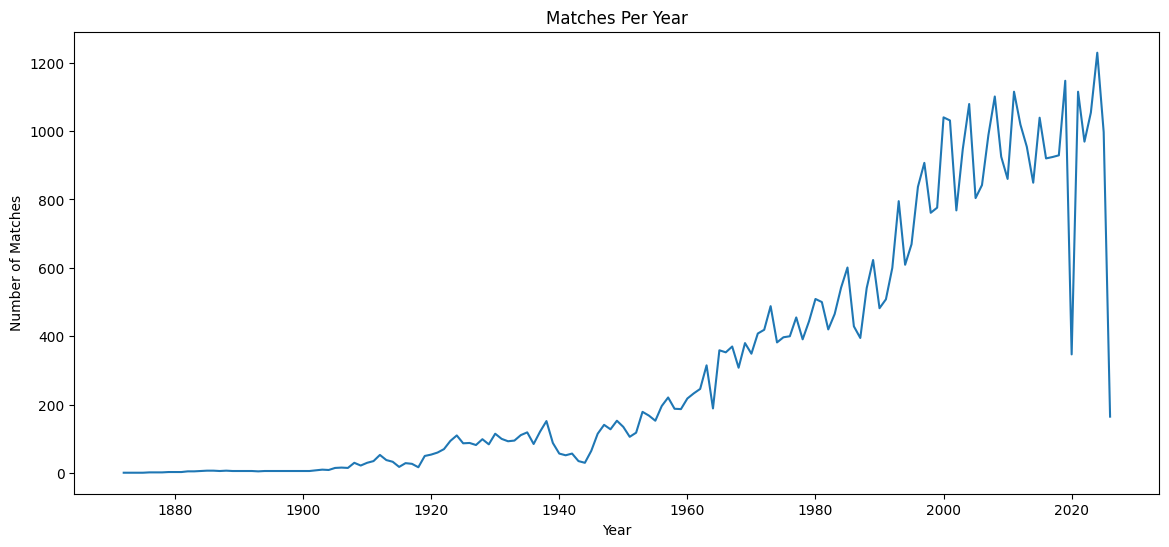

In [16]:
# =========================
# MATCHES PER YEAR
# =========================

matches_per_year = eda_df["year"].value_counts().sort_index()

print(matches_per_year.tail(30))

matches_per_year.plot(
    figsize=(14, 6),
    title="Matches Per Year"
)

plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.show()

In [17]:
# =========================
# DATA FROM 2006+
# =========================

modern_df = eda_df[eda_df["year"] >= 2006].copy()

print("Shape from 2006:", modern_df.shape)
print("Date range:", modern_df["date"].min(), "->", modern_df["date"].max())
print("Teams:", modern_df["home_team"].nunique())
print("Tournaments:", modern_df["tournament"].nunique())

modern_df.head()

Shape from 2006: (19488, 12)
Date range: 2006-01-02 00:00:00 -> 2026-03-31 00:00:00
Teams: 309
Tournaments: 108


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals,goal_diff
29727,2006-01-02,Qatar,Libya,2,0,Friendly,Doha,Qatar,False,2006,2,2
29728,2006-01-05,Egypt,Zimbabwe,2,0,Friendly,Alexandria,Egypt,False,2006,2,2
29729,2006-01-07,Guinea,Togo,1,0,Friendly,Viry-Châtillon,France,True,2006,1,1
29730,2006-01-09,Morocco,DR Congo,3,0,Friendly,Rabat,Morocco,False,2006,3,3
29731,2006-01-11,Ghana,Togo,0,1,Friendly,Monastir,Tunisia,True,2006,1,-1


In [18]:
# =========================
# TOURNAMENT DISTRIBUTION
# =========================

modern_df["tournament"].value_counts().head(30)

tournament
Friendly                                 6353
FIFA World Cup qualification             4234
UEFA Euro qualification                  1322
African Cup of Nations qualification     1182
UEFA Nations League                       658
African Cup of Nations                    429
CONCACAF Nations League                   422
AFC Asian Cup qualification               368
FIFA World Cup                            320
Gold Cup                                  275
COSAFA Cup                                255
CECAFA Cup                                234
CFU Caribbean Cup qualification           226
UEFA Euro                                 215
Island Games                              204
AFC Asian Cup                             198
Copa América                              196
AFF Championship                          184
Gulf Cup                                  137
EAFF Championship                         104
SAFF Cup                                  104
CONIFA World Football C

In [19]:
# =========================
# GOALS ANALYSIS
# =========================

modern_df[["home_score", "away_score", "total_goals", "goal_diff"]].describe()

,home_score,away_score,total_goals,goal_diff
count,19488.000000,19488.000000,19488.000000,19488.000000
mean,1.608734,1.111607,2.720341,0.497126
std,1.633688,1.338111,1.913025,2.293315
min,0.000000,0.000000,0.000000,-20.000000
25%,0.000000,0.000000,1.000000,-1.000000
50%,1.000000,1.000000,2.000000,0.000000
75%,2.000000,2.000000,4.000000,2.000000
max,21.000000,20.000000,22.000000,20.000000


In [20]:
# =========================
# RESULT DISTRIBUTION
# =========================

modern_df["result"] = np.where(
    modern_df["home_score"] > modern_df["away_score"], "home_win",
    np.where(modern_df["home_score"] < modern_df["away_score"], "away_win", "draw")
)

modern_df["result"].value_counts(normalize=True)

result
home_win    0.478859
away_win    0.289101
draw        0.232040
Name: proportion, dtype: float64

In [21]:
# =========================
# LOAD FIFA RANKING DATA
# =========================

rankings = pd.read_csv("../data/raw/fifa_mens_rank.csv")

print("Shape:", rankings.shape)
print(rankings.columns)

rankings.head()

Shape: (13130, 8)
Index(['date', 'semester', 'rank', 'team', 'acronym', 'total.points', 'previous.points', 'diff.points'], dtype='str')


,date,semester,rank,team,acronym,total.points,previous.points,diff.points
0,2024,2,1,Argentina,ARG,1867.25,1883.50,-16.25
1,2024,2,2,France,FRA,1859.78,1859.85,-0.07
2,2024,2,3,Spain,ESP,1853.27,1844.33,8.94
3,2024,2,4,England,ENG,1813.81,1807.83,5.98
4,2024,2,5,Brazil,BRA,1775.85,1784.37,-8.52


In [22]:
# =========================
# FIFA RANKING BASIC INFO
# =========================

rankings.info()

<class 'pandas.DataFrame'>
RangeIndex: 13130 entries, 0 to 13129
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             13130 non-null  int64  
 1   semester         13130 non-null  int64  
 2   rank             13130 non-null  int64  
 3   team             13130 non-null  str    
 4   acronym          13130 non-null  str    
 5   total.points     13130 non-null  float64
 6   previous.points  13130 non-null  float64
 7   diff.points      13130 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 970.9 KB


In [23]:
# =========================
# FIFA RANKING MISSING VALUES
# =========================

rankings.isnull().sum()

date               0
semester           0
rank               0
team               0
acronym            0
total.points       0
previous.points    0
diff.points        0
dtype: int64

In [24]:
# =========================
# FIFA RANKING DATE CHECK
# =========================

rankings.head(20)

,date,semester,rank,team,acronym,total.points,previous.points,diff.points
0,2024,2,1,Argentina,ARG,1867.25,1883.50,-16.25
1,2024,2,2,France,FRA,1859.78,1859.85,-0.07
2,2024,2,3,Spain,ESP,1853.27,1844.33,8.94
3,2024,2,4,England,ENG,1813.81,1807.83,5.98
4,2024,2,5,Brazil,BRA,1775.85,1784.37,-8.52
5,2024,2,6,Portugal,POR,1756.12,1752.68,3.44
6,2024,2,7,Netherlands,NED,1747.55,1748.24,-0.69
7,2024,2,8,Belgium,BEL,1740.62,1761.27,-20.65
8,2024,2,9,Italy,ITA,1731.51,1729.40,2.11
9,2024,2,10,Germany,GER,1703.79,1703.59,0.20
